## Sentiment Analysis

In this exercise we use the IMDb-dataset, which we will use to perform a sentiment analysis. The code below assumes that the data is placed in the same folder as this notebook. We see that the reviews are loaded as a pandas dataframe, and print the beginning of the first few reviews.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
reviews = pd.read_csv('reviews.txt', header=None)
labels = pd.read_csv('labels.txt', header=None)
Y = (labels=='positive').astype(np.int_)

print(type(reviews))
print(reviews.head())

<class 'pandas.DataFrame'>
                                                   0
0  bromwell high is a cartoon comedy . it ran at ...
1  story of a man who has unnatural feelings for ...
2  homelessness  or houselessness as george carli...
3  airport    starts as a brand new luxury    pla...
4  brilliant over  acting by lesley ann warren . ...


 **(a)** Split the reviews and labels in test, train and validation sets. The train and validation sets will be used to train your model and tune hyperparameters, the test set will be saved for testing. Use the `CountVectorizer` from `sklearn.feature_extraction.text` to create a Bag-of-Words representation of the reviews. Only use the 10,000 most frequent words (use the `max_features`-parameter of `CountVectorizer`).

In [2]:
from sklearn.model_selection import train_test_split

# remove punctuation and convert to lowercase
reviews_lower = reviews[0].str.lower().str.replace(".", "", regex=False)


X_train_val, X_test, y_train_val, y_test = train_test_split(reviews_lower, labels, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)
X_train

6911     the     michael keaton kiddie comedy of the sa...
17960    beautiful film  pure cassavetes style  gena ro...
13714    i wonder what audiences of the day thought whe...
15813    leonard maltin compared this film to a mel bro...
22169    let me start out by saying i can enjoy just ab...
                               ...                        
6111     there are times when finishing a film one wish...
4060       dick tracy  is one of our family  s favorite...
23690    sidney stratton is having trouble maintaining ...
18776    i couldn  t believe the comments made about th...
23557    this is only the second time i stopped a video...
Name: 0, Length: 16000, dtype: str

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=10000)

X_train_bow = cv.fit_transform(X_train)
X_train_df = pd.DataFrame(X_train_bow.toarray(), columns=cv.get_feature_names_out())
X_train_df.sum().sort_values(ascending=False)

the          214051
and          104858
of            92632
to            86410
is            68591
              ...  
cocktail         19
trinity          19
closeup          19
clouds           19
precision        19
Length: 10000, dtype: int64

In [4]:
#Transform the validation and test set using the same vocabulary

X_val_bow = cv.transform(X_val)
X_test_bow = cv.transform(X_test)

X_val_df = pd.DataFrame(X_val_bow.toarray(), columns=cv.get_feature_names_out())
X_test_df = pd.DataFrame(X_test_bow.toarray(), columns=cv.get_feature_names_out())

y_train_df = y_train[0].replace({'positive': '1', 'negative': '0'})
y_val_df = y_val[0].replace({'positive': '1', 'negative': '0'})
y_test_df = y_test[0].replace({'positive': '1', 'negative': '0'})


## **(b)** Explore the representation of the reviews. How is a single word represented? How about a whole review?

In the Bag-of-Words representation, each unique word in the dataset is treated as a feature. A single word is represented as a vector where only the corresponding feature is active (typically 1 if present, 0 otherwise).

A whole review is represented as a vector of word counts, where each element corresponds to the frequency of a specific word in the review. This results in a high-dimensional vector where each dimension represents a word from the vocabulary.

In this representation, rows correspond to reviews and columns correspond to words. The values indicate how often each word appears in a given review.

However, Bag-of-Words does not capture word order or context, which is a limitation of this approach.

## **(c)** Train a neural network with a single hidden layer on the dataset, tuning the relevant hyperparameters to optimize accuracy.

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
tf.random.set_seed(42) # tensorflow random state
model = Sequential()
model.add(Input(shape=(X_train_df.shape[1],)))
model.add(Dense(16, activation='tanh'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))
custom_SGD = SGD(learning_rate=0.1)
model.compile(
    optimizer=custom_SGD,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

X_train_df_np = np.asarray(X_train_df).astype(np.float32)
X_val_df_np = np.asarray(X_val_df).astype(np.float32)

y_train_np = np.asarray(y_train_df).astype(np.float32)
y_val_df_np = np.asarray(y_val_df).astype(np.float32)
y_test_df_np = np.asarray(y_test_df).astype(np.float32)

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = model.fit(
    X_train_df_np, y_train_np,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

I0000 00:00:1776077756.678491  108052 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
W0000 00:00:1776077757.974288  108052 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6850 - loss: 0.5922 - val_accuracy: 0.7328 - val_loss: 0.5067
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7763 - loss: 0.4802 - val_accuracy: 0.7694 - val_loss: 0.4538
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7963 - loss: 0.4401 - val_accuracy: 0.7653 - val_loss: 0.4564
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8220 - loss: 0.4028 - val_accuracy: 0.8266 - val_loss: 0.3809
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8349 - loss: 0.3807 - val_accuracy: 0.7922 - val_loss: 0.4136
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8494 - loss: 0.3568 - val_accuracy: 0.8491 - val_loss: 0.3428
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8458 - loss: 0.3553 - val_accuracy: 0.8275 - val_loss: 0.3867
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8630 - loss: 0.3245 - val_accuracy: 0.

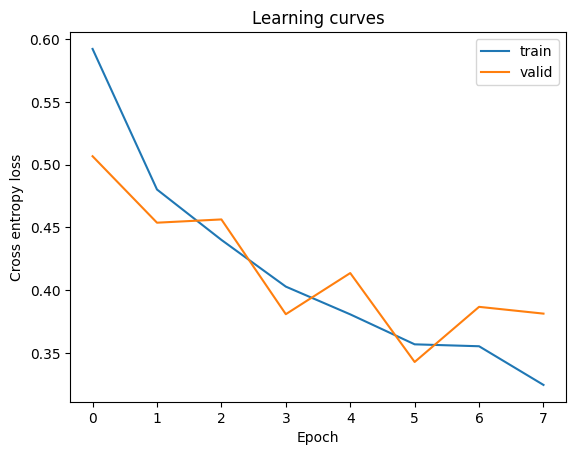

In [6]:
plt.figure()
plt.title("Learning curves")
plt.xlabel("Epoch")
plt.ylabel("Cross entropy loss")
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'valid')
plt.legend()
plt.show()

In [7]:
train_results = model.evaluate(X_train_df_np, y_train_np, verbose=0)
val_results = model.evaluate(X_val_df_np, y_val_df_np, verbose=0)

print(f"Loss + accuracy on train data: {train_results}")
print(f"Loss + accuracy on validation data: {val_results}")

W0000 00:00:1776077763.542153  108052 cpu_allocator_impl.cc:82] Allocation of 640000000 exceeds 10% of free system memory.


Loss + accuracy on train data: [0.30490002036094666, 0.8743125200271606]
Loss + accuracy on validation data: [0.3429429233074188, 0.8557500243186951]


## **(d)** Test your sentiment-classifier on the test set.

In [8]:
test_results = model.predict(X_test_df)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step


In [9]:
test_loss, test_acc = model.evaluate(X_test_df, np.asarray(y_test_df).astype(np.float32), verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.3414517641067505
Test accuracy: 0.853600025177002


## **(e)** Use the classifier to classify a few sentences you write yourselves.

In [11]:
my_sentences = [
    "This film is an absolute masterpiece. The storytelling is deeply moving, the characters are unforgettable, and the emotional payoff is incredibly powerful. Every scene feels meaningful, and it leaves a lasting impression long after it ends.",

    "This movie is a complete mess. The plot is incoherent, the characters are shallow, and the endless explosions quickly become exhausting. It feels loud, chaotic, and painfully empty.",

    "A brilliant and sharply crafted film that blends genres effortlessly. The writing is intelligent, the direction is flawless, and the social commentary is both subtle and impactful. It is gripping from start to finish.",

    "An utterly baffling and uncomfortable experience. The visual effects are unsettling, the story is nearly nonexistent, and the entire film feels like a strange mistake that should never have been made.",

    "An exceptional film that elevates the superhero genre to something far more serious and compelling. The performances are outstanding, especially Heath Ledger, whose portrayal is unforgettable.",

    "This film is disastrously bad. The acting is unnatural, the dialogue is nonsensical, and the plot is incoherent. It fails on nearly every level of filmmaking.",

    "A visually stunning and emotionally powerful film. It combines ambitious scientific ideas with a deeply human story, creating an experience that is both thought-provoking and moving.",

    "A disappointing and poorly structured film. The pacing is uneven, the story lacks focus, and the characters are underdeveloped. It feels like a missed opportunity in every way.",

    "An outstanding animated film with incredible visuals and a heartfelt story. It is creative, energetic, and emotionally engaging from beginning to end.",

    "A dull and poorly executed film. The performances lack depth, the dialogue is awkward, and the story feels slow and unconvincing. It struggles to hold attention."
]
my_sentences_vec = cv.transform(my_sentences)
my_sentences_vec_df = pd.DataFrame(my_sentences_vec.toarray(), columns=cv.get_feature_names_out())

predictions = model.predict(my_sentences_vec_df)
pred_labels = (predictions > 0.5).astype(int)
for sentence, prob, label in zip(my_sentences, predictions, pred_labels):
    sentiment = "Positive" if label == 1 else "Negative"
    print(f"Sentence: {sentence}")
    print(f"Prediction: {sentiment} (prob={prob[0]:.3f})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Sentence: This film is an absolute masterpiece. The storytelling is deeply moving, the characters are unforgettable, and the emotional payoff is incredibly powerful. Every scene feels meaningful, and it leaves a lasting impression long after it ends.
Prediction: Positive (prob=0.800)

Sentence: This movie is a complete mess. The plot is incoherent, the characters are shallow, and the endless explosions quickly become exhausting. It feels loud, chaotic, and painfully empty.
Prediction: Negative (prob=0.166)

Sentence: A brilliant and sharply crafted film that blends genres effortlessly. The writing is intelligent, the direction is flawless, and the social commentary is both subtle and impactful. It is gripping from start to finish.
Prediction: Positive (prob=0.871)

Sentence: An utterly baffling and uncomfortable experience. The visual effects are unsettling, the story is nearly nonexistent, and the entire film feels like a strange mistake that shou